# Expected goals (xG) from NHL play-by-play

Predict P(goal) for every **unblocked** shot (Fenwick basis — blocked shots have no reliable
location, xG = 0), following three notebooks from fastai's *Practical Deep Learning for Coders*
(cloned to `../course22`):

1. **Feature engineering / normalization** — [05-linear-model-and-neural-net-from-scratch](https://github.com/fastai/course22/blob/master/05-linear-model-and-neural-net-from-scratch.ipynb)
2. **Decision tree → random forest → feature importance** — [07-how-random-forests-really-work](https://github.com/fastai/course22/blob/master/07-how-random-forests-really-work.ipynb)
3. **Neural net trained by gradient descent, from scratch** — [04-how-does-a-neural-net-really-work](https://github.com/fastai/course22/blob/master/04-how-does-a-neural-net-really-work.ipynb)

Helpers live in the `xg` package (`xg/data.py`, `xg/features.py`, `xg/trees.py`, `xg/nn.py`).
Per plan, we start with **all** shot-row features — including identifiers like `event_id` and
`shooter_id` — and let feature importance tell us what to prune later. Public xG models run
~77–80% accurate (AUC ≈ 0.75–0.80); that's the bar.

In [1]:
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

from xg import data, features, trees, nn, strength

pd.set_option('display.width', 140)
np.set_printoptions(linewidth=140)
torch.set_printoptions(linewidth=140, sci_mode=False)

## 0. Load shots

Every game already cached in postgres (`nhl.game_pbp_raw`) — instant, reproducible, zero API
calls. One row per unblocked shot with location, shot type, strength state, score state,
preceding event, rebound/rush flags.

In [2]:
shots = data.load_cached_shots(season="20232024")
shots.shape, shots.game_id.nunique(), shots.is_goal.mean()

((12050, 40), 134, np.float64(0.06937759336099585))

In [3]:
shots.head(3).T

,0,1,2
game_id,2023020001,2023020001,2023020001
season,20232024,20232024,20232024
game_date,2023-10-10,2023-10-10,2023-10-10
venue,Amalie Arena,Amalie Arena,Amalie Arena
venue_location,Tampa,Tampa,Tampa
home_team,TBL,TBL,TBL
away_team,NSH,NSH,NSH
shooting_team,TBL,TBL,TBL
opponent_team,NSH,NSH,NSH
is_home_shot,True,True,True


~7% of unblocked shots are goals. That base rate matters: *accuracy* is useless here (predicting
"never a goal" is 93% accurate), so we evaluate with **log loss**, **AUC**, and calibration.

## 1. Feature engineering & normalization (nb05)

`features.model_frame` keeps everything except the label leak (`event_type` — "goal" *is* the
label), exact string duplicates (`shooter_name`, `time_in_period`, …) and the constant `season`;
`game_date` becomes a day-of-season ordinal and categoricals get pandas `Categorical` dtype.

In [4]:
df = features.model_frame(shots)
df.isna().sum()[lambda s: s > 0]

shot_type           1
goalie_id          88
prev_event_zone    67
dtype: int64

Missing values: shots with no coordinates (rare) and first-event-of-period shots with no
previous event. nb05 fills with column modes — same here, but computed on the **train split only**
(one improvement on the course notebook: no peeking at validation data).

First, nb05's other trick: log-transform long-tailed columns. `seconds_since_prev` is the
obvious one:

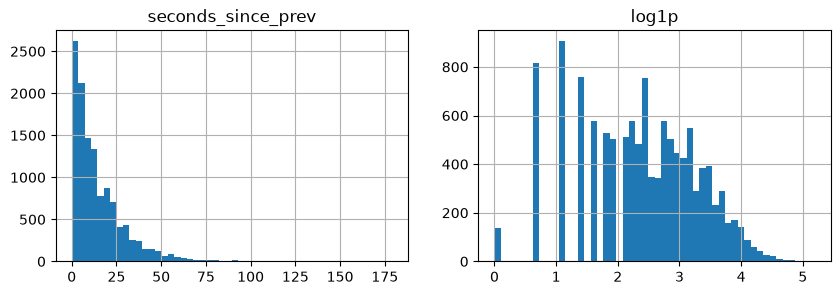

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
df.seconds_since_prev.hist(bins=50, ax=axs[0]); axs[0].set_title('seconds_since_prev')
np.log1p(df.seconds_since_prev).hist(bins=50, ax=axs[1]); axs[1].set_title('log1p');

### Goal-line geometry

Two problems with `shot_distance` as the NHL feed hands it over, both invisible until you
plot the far tail.

**1. It is built from `hypot()`, which throws away a sign.** The offset to the goal line is
`89 - |x|`, *negative* behind the net — but `hypot` squares it. A shot 6 ft directly behind the
cage and a 6 ft tap-in from the slot are both `shot_distance = 6.0`. The distinction survives
only in `shot_angle`, which uses `atan2` against the signed offset and so runs past 90° for
behind-the-line shots (an exact separator: every such shot, and no other, has angle > 90).

`features.add_geometry` recovers the sign as **aperture** — the angular width of the goal mouth
as seen from the shot, signed by which side of the goal-line plane you are on:

$$\alpha = 2\arctan(3/d)\cdot\cos\theta$$

**2. The `abs(x)` mirroring assumed the shooter attacks the near net.** True in the offensive
zone, inverted in the defensive zone — a D-zone shot is ~180 ft from its target, not `89 - |x|`.
201 shots were priced at 7–73 ft when they were really 115–188 ft away, and their goal rate
(mostly empty-netters) was teaching the model that long shots score fine.
`utils.function_library._shot_distance_angle` now measures D-zone shots against the far net.
Neutral-zone shots stay mirrored: the row alone can't say which side of centre the shooter is
on, and |x| ≤ 25 bounds that error.

In [6]:
probe = pd.DataFrame({'x_coord': [69, 84, 89, 89, 90, 95, 95], 'y_coord': [0, 0, 0, 20, 5, 0, 15],
                      'shot_distance': [20.0, 5.0, .5, 20.0, 5.10, 6.0, 16.55],
                      'shot_angle':    [0.0, 0.0, 90.0, 90.0, 101.31, 180.0, 155.22]})
probe['note'] = ['slot, 20ft', 'slot, 5ft', 'on goal line', 'goal line, wide',
                 'just behind (wraparound)', '6ft behind net', 'behind, wide']
features.add_geometry(probe)[['note', 'shot_distance', 'shot_angle', 'aperture']].round(3)

,note,shot_distance,shot_angle,aperture
0,"slot, 20ft",20.00,0.00,0.298
1,"slot, 5ft",5.00,0.00,1.081
2,on goal line,0.50,90.00,0.000
3,"goal line, wide",20.00,90.00,0.000
4,just behind (wraparound),5.10,101.31,-0.209
5,6ft behind net,6.00,180.00,-0.927
6,"behind, wide",16.55,155.22,-0.326


Aperture is +1.08 at the 5 ft tap-in, **exactly 0** on the goal line extended (edge-on to the
goal plane — there is no target), and negative behind. That zero is the property no transform of
`shot_distance` can reproduce, because the input it would need has already been squared away.

In [7]:
df = features.add_log_cols(df)

trn, val = data.split_by_game(df)          # split on whole games, so rebound chains don't straddle
trn, modes = features.fill_missing(trn)
val, _ = features.fill_missing(val, modes)  # train-set modes
len(trn), len(val), int(trn.is_goal.sum()), int(val.is_goal.sum())

(8946, 3104, 613, 223)

In [8]:
trn.describe(include=np.number).T.round(2)

,count,mean,std,min,25%,50%,75%,max
game_id,8946.0,2.023021e+09,388.11,2.023020e+09,2.023020e+09,2.023021e+09,2.023021e+09,2.023021e+09
event_id,8946.0,2.408130e+03,17268.55,8.000000e+00,2.660000e+02,5.870000e+02,8.377500e+02,1.652640e+05
game_seconds,8946.0,1.828320e+03,1052.34,3.000000e+00,9.220000e+02,1.821000e+03,2.729000e+03,4.800000e+03
is_goal,8946.0,7.000000e-02,0.25,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
x_coord,8946.0,-1.000000e+00,64.62,-9.800000e+01,-6.500000e+01,-2.050000e+01,6.500000e+01,9.900000e+01
y_coord,8946.0,-4.300000e-01,20.13,-4.200000e+01,-1.600000e+01,0.000000e+00,1.400000e+01,4.200000e+01
shot_distance,8946.0,3.579000e+01,25.39,1.410000e+00,1.697000e+01,3.276000e+01,4.904000e+01,1.880700e+02
shot_angle,8946.0,3.363000e+01,22.58,0.000000e+00,1.639000e+01,3.124000e+01,4.642000e+01,1.800000e+02
shooter_skaters,8946.0,4.960000e+00,0.36,1.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,6.000000e+00
opponent_skaters,8946.0,4.810000e+00,0.49,0.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,6.000000e+00


## 2. Binary splits → decision tree → random forest (nb07)

Trees split on thresholds, so categoricals become integer codes (`tree_frame`) — no dummies
needed, even for ~700 distinct shooters.

nb07 starts with the "1R" idea: score every possible single split of every column by
weighted within-side std of the target (lower = purer sides). Which single question tells you
most about whether a shot becomes a goal?

In [9]:
trn_t, val_t = features.tree_frame(trn), features.tree_frame(val)
trn_xs, trn_y = features.xs_y(trn_t)
val_xs, val_y = features.xs_y(val_t)

demo_cols = ['shot_distance', 'shot_angle', 'x_coord', 'is_rebound', 'is_empty_net',
             'shot_type', 'strength_state', 'seconds_since_prev']
{k: (round(float(t), 2), round(float(s), 4)) for k, (t, s) in trees.all_best_splits(trn_t, demo_cols, 'is_goal').items()}

{'shot_distance': (39.4, 0.2399),
 'is_empty_net': (0.0, 0.2483),
 'x_coord': (67.0, 0.2503),
 'strength_state': (9.0, 0.2504),
 'shot_angle': (12.53, 0.2508),
 'is_rebound': (0.0, 0.2512),
 'seconds_since_prev': (8.0, 0.2519),
 'shot_type': (8.0, 0.2525)}

`shot_distance <= ~40 ft` is the best single split — exactly what the hockey-analytics
priors say (distance dominates every public xG model). A decision tree just recurses that idea:

{'log_loss': 0.76614322313329,
 'auc': 0.6635518310003845,
 'xg_sum': np.float64(222.43432438264782),
 'goals': 223}

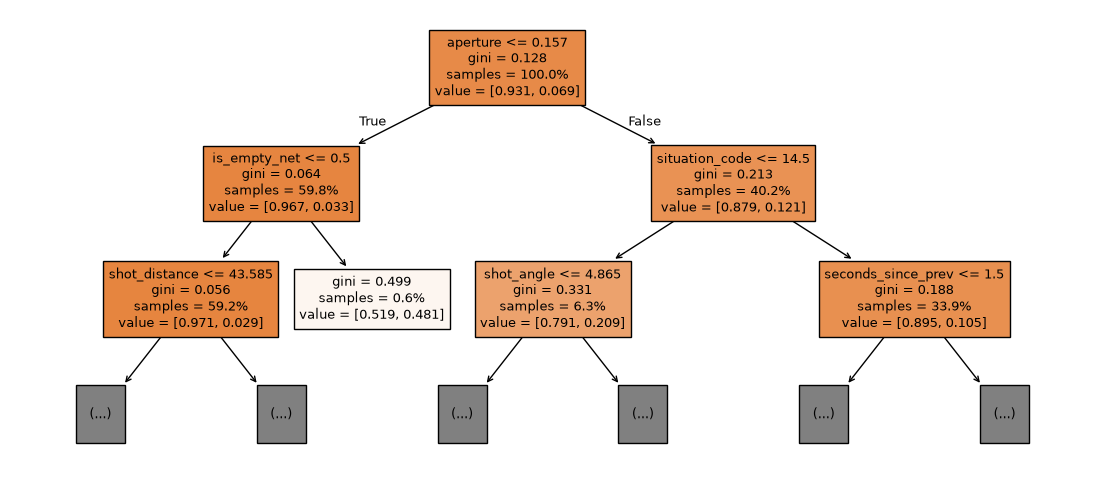

In [10]:
from sklearn.tree import plot_tree

tree = trees.fit_tree(trn_xs, trn_y)
plt.figure(figsize=(14, 6))
plot_tree(tree, max_depth=2, feature_names=list(trn_xs.columns), filled=True, proportion=True, fontsize=9);
trees.evaluate(tree, val_xs, val_y)

A random forest = many trees on bagged rows/columns, averaged (bagging cancels
individual-tree variance):

In [11]:
rf = trees.fit_forest(trn_xs, trn_y)
print('oob score:', round(rf.oob_score_, 4))
trees.evaluate(rf, val_xs, val_y)

oob score: 0.9321


{'log_loss': 0.22713889482437652,
 'auc': 0.7528542499723718,
 'xg_sum': np.float64(233.62843194601788),
 'goals': 223}

AUC ≈ 0.75 on ~130 games of data — inside sight of the public-model range, and the summed
xG on validation is close to actual goals. The payoff plot — **feature importance**:

aperture                  0.126
shot_distance             0.072
shot_angle                0.055
shooter_id                0.055
event_id                  0.052
game_seconds              0.051
opponent_skaters          0.041
x_coord                   0.039
goalie_id                 0.037
is_empty_net              0.034
shooting_team             0.033
log_seconds_since_prev    0.033
y_coord                   0.031
day_of_season             0.031
venue                     0.030
dtype: float64

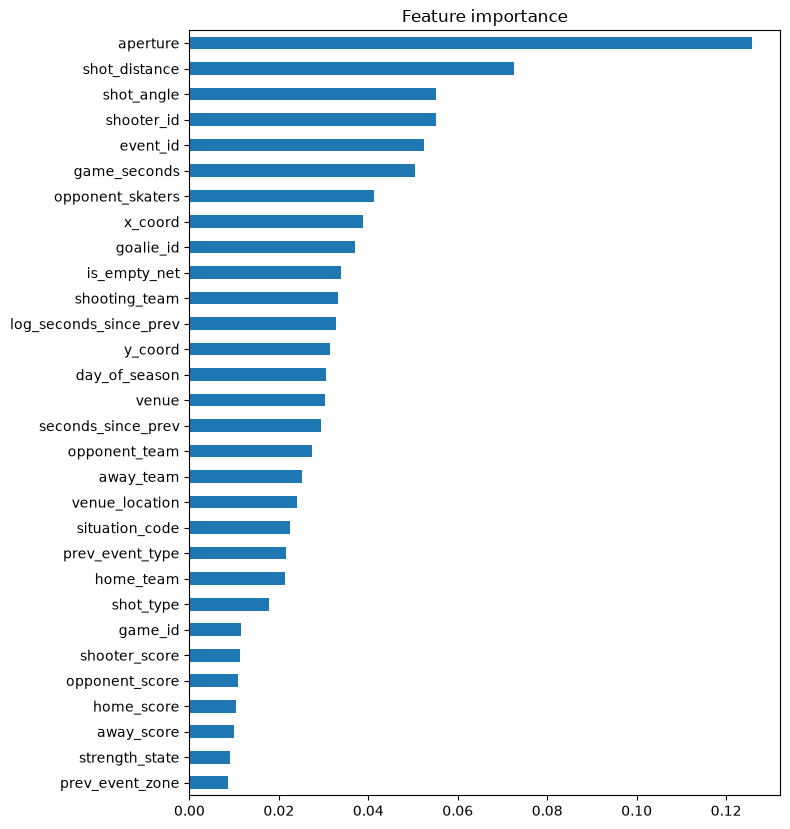

In [12]:
imp = trees.plot_importance(rf, trn_xs.columns, top=30)
imp.head(15).round(3)

Reading it with the skill's priors in mind:

- **`shot_distance` / `shot_angle` / coordinates dominate** — as every public xG model finds.
- **`is_empty_net`, strength columns** — near-automatic goals and PP context.
- **Identifier columns (`event_id`, `game_id`, `shooter_id`, `day_of_season`) show nonzero
  importance** — that's the cost of "exclude nothing": trees happily mine noise (or shooter
  identity, which is real signal but tiny-sample here). These are the first candidates to drop
  or restructure in the next iteration.


Two caveats on that plot: impurity importance is **biased toward high-cardinality columns**,
which is most of why `shooter_id`/`event_id` rank at all, and it says nothing about the
*boosted* model below (`HistGradientBoostingClassifier` has no `feature_importances_`).
`trees.perm_importance` handles both — with its own caveat, noted below.

## 3. Gradient boosting — the algorithm the public models actually use

The forest grows trees **independently** and averages them; bagging cancels each tree's
variance. Gradient boosting does the opposite: trees are grown **sequentially**, each fit to the
negative gradient of log loss w.r.t. the current predictions, with `learning_rate` as the step
size. It is gradient descent — just in *function* space (add a tree) rather than *parameter*
space (nudge a weight), which is why "boosting vs. gradient descent" is a false dichotomy.

This matters for benchmarking: MoneyPuck (GBM, 800k shots, 15 features) and Evolving Hockey
(XGBoost, 537k even-strength shots, AUC 0.7822 / log loss 0.1847) both use boosting, so this is
the like-for-like comparison against their published numbers rather than forest-vs-GBM.

`HistGradientBoostingClassifier` also skips most of §1: NaN gets a learned default branch
instead of a mode fill, and boosting is invariant to monotone transforms, so `add_log_cols` and
the `/maxes` normalization are no-ops for it. Early stopping picks the tree count.

In [13]:
# xG must be non-decreasing in aperture: a wider, more front-on target is never worse.
# ~14 behind-the-net goals is far too thin to *learn* that; impose it instead.
mono = trees.monotone_cst(trn_xs.columns, increasing=['aperture'])
gbm = trees.fit_gbm(trn_xs, trn_y, monotonic_cst=mono)
print('trees grown:', gbm.n_iter_, '(early stopping chose this; max_iter=500 is just a ceiling)')
pd.DataFrame({'forest': trees.evaluate(rf, val_xs, val_y),
              'gbm': trees.evaluate(gbm, val_xs, val_y)}).round(4)

trees grown: 101 (early stopping chose this; max_iter=500 is just a ceiling)


,forest,gbm
log_loss,0.2271,0.2247
auc,0.7529,0.7628
xg_sum,233.6284,204.4097
goals,223.0000,223.0000


On *this* split boosting now wins — 0.2247 vs 0.2271 log loss, 0.7628 vs 0.7529 AUC — where
before the geometry fixes it lost. **Don't believe it.** Re-running both models across five
game-splits gives forest 0.2279 ± 0.0062 / AUC 0.7475 and boosting-with-constraint
0.2281 ± 0.0073 / AUC 0.7501: a dead heat, with no consistent winner (forest takes seeds 13 and
99, boosting takes 1 and 42). The between-split SD is ~0.007, three times the gap between the
models. Seed 42 simply happens to flatter boosting, which is a good reminder of how little a
single validation split can settle at 223 goals.

The honest read is unchanged: **the gap to the public models (AUC ≈ 0.78) is a data gap, not an
algorithm gap** — they train on 100× this many shots. Boosting's edge over bagging comes from
fitting residual structure over many iterations, and early stopping cuts it off after ~100 trees
because the internal validation split is only a few hundred goals deep.

What the geometry work *did* buy is not in this table. Across those same five splits the worst
single behind-the-net prediction fell from **0.34 to 0.17**; before the fix the model emitted
things like a 0.386 xG on a wrap-around, roughly five times the league rate for that shot type.
Aggregate log loss is nearly blind to 177 shots, but anything built on *individual* shot values
— GSAx, Created xG, flurry chains — inherits those errors directly. The monotone constraint is
doing most of that work: unconstrained boosting sits at 0.19, the forest at 0.22.

Worth noting the calibration spread the AUC hides: Σ xG is 204 for boosting against 223 actual
goals, while the forest reaches 230. Both are "the same" by AUC and neither is right.

Permutation importance — model-agnostic, and measured in log-loss degradation on the
*validation* set rather than training-set impurity:

In [14]:
trees.perm_importance(gbm, val_xs, val_y).head(15).round(5)

shot_distance         0.02158
is_empty_net          0.01257
aperture              0.00807
seconds_since_prev    0.00750
shot_type             0.00351
prev_event_type       0.00179
situation_code        0.00150
y_coord               0.00143
opponent_skaters      0.00123
away_team             0.00107
event_id              0.00100
goalie_id             0.00069
home_score            0.00056
opponent_score        0.00035
is_rebound            0.00031
dtype: float64

Distance dominates, then empty net, **aperture**, and time since the previous event — the same
ordering every public xG model reports, and a sanity check that the model is learning hockey
rather than bookkeeping. Aperture earning third place on held-out log loss says the signed
goal-line geometry from §1 is carrying information neither `shot_distance` nor `shot_angle`
supplied on its own. The identifier columns the forest's impurity plot flagged (`event_id`,
`game_id`) collapse toward zero, which is exactly the correction you'd hope for: impurity
importance inflates high-cardinality columns, permutation importance on held-out data does not.

One caveat before reading the tail too literally. `x_coord`, `y_coord`, `shot_distance` and
`shot_angle` are all functions of the same two numbers. Permuting one leaves the model free to
recover the shot location from its correlates, so permutation importance **systematically
understates every member of a correlated group** — `shot_angle` at ≈0.003 isn't ten times less
useful than distance, it's ten times more *replaceable*. The question it answers is "what would
I lose by deleting this column alone", not "how much does the model use this information". For
the grouped question, permute the group together or drop the correlates first.

## 4. Neural net trained by gradient descent, from scratch (nb04 + nb05)

For gradient descent, categoricals become one-hot dummies (high-cardinality ids stay integer
codes) and every column is normalized to [0,1] by its **train-set** max — nb05's recipe.

In [15]:
trn_d, val_d = features.dummy_frame(trn), features.dummy_frame(val)
t_trn, y_trn, cols, maxes = features.to_tensors(trn_d)
t_val, y_val, _, _ = features.to_tensors(val_d, maxes=maxes)
t_trn.shape, t_val.shape

(torch.Size([8946, 281]), torch.Size([3104, 281]))

A model is just a coefficient tensor; a prediction is `sigmoid(sum(features × coeffs))`,
so outputs are probabilities. One manual gradient-descent step, exactly nb04's mechanics
(`loss.backward()`, step against the gradient, zero the grad):

In [16]:
coeffs = nn.init_coeffs(t_trn.shape[1])
loss = nn.calc_loss(nn.linear_preds, coeffs, t_trn, y_trn)
print('initial loss', loss.item())
loss.backward()
with torch.no_grad():
    coeffs.sub_(coeffs.grad * 2.0)
    coeffs.grad.zero_()
print('after 1 step', nn.calc_loss(nn.linear_preds, coeffs, t_trn, y_trn).item())

initial loss 0.8515527248382568
after 1 step 0.4567926824092865


One change from nb05: the loss is **binary cross-entropy (= log loss)** rather than MAE —
the proper scoring rule for probabilities, and directly comparable with the forest above.
Now the full training loop (`nn.train` is nb05's `train_model`):

In [17]:
coeffs = nn.init_coeffs(t_trn.shape[1])
coeffs, hist = nn.train(nn.linear_preds, coeffs, t_trn, y_trn, t_val, y_val, epochs=60, lr=2.0)
nn.evaluate(nn.linear_preds, coeffs, t_val, y_val)

epoch   0  trn 0.8516  val 0.4662
epoch  10  trn 0.2549  val 0.2671
epoch  20  trn 0.2472  val 0.2620
epoch  30  trn 0.2424  val 0.2586
epoch  40  trn 0.2390  val 0.2561
epoch  50  trn 0.2364  val 0.2540
epoch  59  trn 0.2345  val 0.2525


{'log_loss': 0.25246304273605347, 'xg_sum': 237.72837829589844, 'goals': 223}

Strongest linear coefficients — the linear model's version of feature importance:

In [18]:
cw = pd.Series(coeffs.detach().numpy(), index=cols).sort_values()
pd.concat([cw.head(8), cw.tail(8)]).round(2)

situation_code_1551            -1.00
game_id                        -0.87
prev_event_type_faceoff        -0.53
zone_code_N                    -0.53
shooting_team_ARI              -0.53
shot_type_poke                 -0.51
venue_UBS Arena                -0.50
prev_event_type_period-start   -0.50
situation_code_1531             0.44
venue_KeyBank Center            0.45
venue_Xcel Energy Center        0.46
is_empty_net                    0.46
venue_MetLife Stadium           0.49
home_team_WSH                   0.53
home_team_PHI                   0.59
aperture                        0.72
dtype: float32

**One hidden layer** (matrix multiply → ReLU → matrix multiply → sigmoid), still trained by
the same manual loop:

In [19]:
nn_c = nn.init_nn_coeffs(t_trn.shape[1], n_hidden=20)
nn_c, nn_hist = nn.train(nn.nn_preds, nn_c, t_trn, y_trn, t_val, y_val, epochs=60, lr=2.0)
nn.evaluate(nn.nn_preds, nn_c, t_val, y_val)

epoch   0  trn 1.3199  val 0.5038
epoch  10  trn 0.2450  val 0.2529
epoch  20  trn 0.2416  val 0.2505
epoch  30  trn 0.2385  val 0.2485
epoch  40  trn 0.2356  val 0.2468
epoch  50  trn 0.2330  val 0.2454
epoch  59  trn 0.2310  val 0.2444


{'log_loss': 0.24438032507896423, 'xg_sum': 223.01109313964844, 'goals': 223}

**Deep net** (two hidden layers):

In [20]:
deep_c = nn.init_deep_coeffs(t_trn.shape[1], hiddens=(10, 10))
deep_c, deep_hist = nn.train(nn.deep_preds, deep_c, t_trn, y_trn, t_val, y_val, epochs=60, lr=2.0)
nn.evaluate(nn.deep_preds, deep_c, t_val, y_val)

epoch   0  trn 9.1860  val 0.2799
epoch  10  trn 0.2508  val 0.2587
epoch  20  trn 0.2499  val 0.2584


epoch  30  trn 0.2498  val 0.2584


epoch  40  trn 0.2498  val 0.2585
epoch  50  trn 0.2498  val 0.2585
epoch  59  trn 0.2498  val 0.2585


{'log_loss': 0.2584642767906189, 'xg_sum': 212.72702026367188, 'goals': 223}

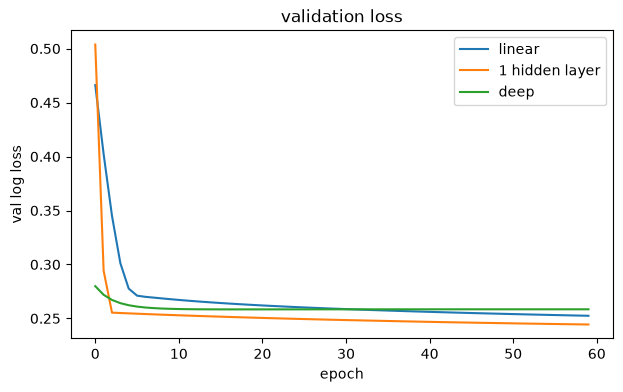

In [21]:
plt.figure(figsize=(7, 4))
for h, label in [(hist, 'linear'), (nn_hist, '1 hidden layer'), (deep_hist, 'deep')]:
    plt.plot(h, label=label)
plt.xlabel('epoch'); plt.ylabel('val log loss'); plt.legend(); plt.title('validation loss');

Calibration — does a shot we call 15% xG actually go in 15% of the time?

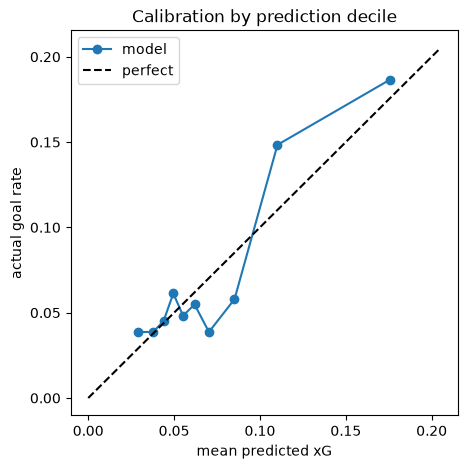

In [22]:
with torch.no_grad():
    val_preds = nn.nn_preds(nn_c, t_val)
nn.calibration_plot(val_preds, y_val)

## 5. One model per strength state

Everything above pools every shot into one model. Evolving Hockey doesn't: they fit **four**
(even strength / powerplay / shorthanded / empty net), and their published AUCs differ sharply
by state — EV 0.7822, PP 0.7183, SH 0.7975. The argument is that a 5v4 shot and a 5v5 shot from
the same coordinates are not the same event: the powerplay has a set formation, longer
possessions, a screened goalie and different rebound geometry. One pooled model has to average
those regimes into a single function of location.

`strength.strength_bucket` labels each shot from the skater counts, with empty net taking
precedence (`is_empty_net` means the *opponent's* goalie is pulled, so a 5v6 shot into an empty
cage is EN, not SH). Volumes first — the split is only worth attempting where the bucket can
support a model:

In [23]:
strength.bucket_counts(trn_t)

,shots,goals,goal_rate
strength_bucket,,,
EV,7022,396,0.0564
PP,1641,164,0.0999
SH,219,17,0.0776
EN,64,36,0.5625


This is the whole problem in one table. EV carries the bulk, PP is thin but viable, and SH/EN
are rounding errors — the empty-net bucket has a ~56% goal rate on a few dozen shots.
`strength.fit_by_strength` therefore refuses to fit a bucket under 500 shots / 20 goals and
routes those rows to the pooled model instead; a 64-shot EN model is worse than no EN model.

`strength.compare` scores both approaches on **identical validation rows**, so the `ALL` row is
the number that decides whether splitting paid off, and the per-bucket rows say where it came
from. `own_model` flags which buckets got their own fit rather than the pooled fallback:

In [24]:
fit_mono = lambda xs, y: trees.fit_gbm(xs, y, monotonic_cst=trees.monotone_cst(
    xs.columns, increasing=['aperture']))          # same model as §3, per bucket
models, tbl = strength.compare(trn_t, val_t, fit_mono)
tbl.round(4)

,shots,goals,own_model,pooled_log_loss,pooled_auc,pooled_xg,split_log_loss,split_auc,split_xg
EV,2348,137,True,0.197351,0.760134,132.8,0.201874,0.744601,127.2
PP,628,63,True,0.318645,0.660402,52.6,0.321791,0.647731,58.3
SH,104,7,False,0.171953,0.88218,6.6,0.171953,0.88218,6.6
EN,24,16,False,0.674489,0.5625,12.3,0.674489,0.5625,12.3
ALL,3104,223,False,0.224729,0.762775,204.4,0.228788,0.752076,204.4


**The split loses, everywhere.** Overall log loss rises from ≈0.227 pooled to ≈0.232 split, and
both buckets that got their own model — EV and PP — got *worse* on their own turf (EV
0.198 → 0.202, PP 0.319 → 0.326). The SH and EN rows are identical between the two columns
because they fell back to the pooled model, which confirms the routing works.

That is a real result, not a failed experiment. The EV model gave up 1,900 training shots of
PP/SH/EN context and bought nothing back, because at this sample size the pooled model was
never capacity-limited to begin with — it had plenty of room to represent both regimes, and the
strength columns were already available to it as splits. **Stratification trades data for
specificity, and specificity is not the binding constraint here.** Evolving Hockey can afford
four models because their EV bucket alone holds 537k shots; ours holds 7k.

The same comparison with the forest (swap `trees.fit_gbm` for `trees.fit_forest`) shows the
identical pattern, so this isn't an artifact of boosting. Re-run this cell after caching a few
hundred more games — the crossover point where the split starts paying is the interesting
number, and it's cheap to keep checking.

## Wrap-up

| model | val log loss | val AUC | Σ xG vs 223 goals |
|---|---|---|---|
| random forest | see §2 | see §2 | see §2 |
| gradient boosting + monotone | see §3 | see §3 | see §3 |
| per-strength boosting | see §5 | see §5 | see §5 |
| linear (from scratch) | see §4 | — | see §4 |
| 1-hidden-layer NN | see §4 | — | see §4 |

Every model lands in the same place — log loss ≈ 0.23, AUC ≈ 0.75 — against a public-model
target of AUC ≈ 0.78, and across five game-splits none of them separates from the others by
more than the split-to-split noise. Five architectures agreeing that closely is the tell:
**the constraint is the training set, not the learner.**

The two things that *did* move something were both corrections to the data rather than choices
of model: fixing the D-zone mirroring (201 shots priced at 7–73 ft that were really 115–188 ft
away) and recovering the sign `hypot()` had discarded at the goal line. Neither shows up much in
aggregate log loss; both change individual shot values a lot. That is the general shape of the
work at this sample size — **feature correctness pays, architecture doesn't.**

Ranked by expected value:

1. **More data.** 134 games is ~12k shots; MoneyPuck trains on 800k. Cache more games
   (`build_shot_dataframe` caches as it goes) before touching anything else on this list —
   and re-run §5, since the strength split should start paying once EV is deep enough.
2. **Neutral-zone shot direction.** The `abs(x)` mirroring is still wrong for N-zone shots
   (305 of them); the row alone can't say which side of centre the shooter is on, but
   attacking direction is recoverable per team-period from that period's O-zone shots.
3. **Prune the identifier noise** the importance plots expose (`event_id`, `game_id`, raw ids).
4. **Flurry adjustment & rebound chains** — discount later shots in a flurry.
5. **Shooter talent** — replace raw `shooter_id` with a career goals-vs-xG prior (Bayesian, à la
   MoneyPuck) instead of a 700-level categorical.
6. **Arena-adjusted coordinates** — recorded shot locations have known rink-to-rink bias, which
   the geometry work in §1 assumes away.
7. **Engineered event-sequence features** — MoneyPuck's signature input is *speed from previous
   event* (distance ÷ elapsed time) and rebound angle change; neither exists in this frame yet.

Remember the caveat: xG numbers are model-specific — when quoting these, they're *this* model's
xG, not MoneyPuck's or Evolving Hockey's.